Empezamos importando pandas para leer el archivo CSV y Excel que es donde se encuentran los valores de CRUspi asia y long, además estos se necesitaran graficar mas adelante y analizar de forma estadistica, por lo que consideramos tambien librerias como matpotlib y seaborn. En este codigo unificamos ambos dataset 

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Estilo
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ── Cargar datos ──────────────────────────────────────────
# CRUspi Longs
df_long = pd.read_csv('../data/crulong_ObservationData_ruzmvmb.csv')
df_long = df_long[['Date', 'Value']].rename(columns={'Value': 'cruspi_longs'})
df_long['date'] = pd.to_datetime(df_long['Date'].str.replace(r'(\d{4})M(\d+)', r'\1-\2-01', regex=True))
df_long = df_long[['date', 'cruspi_longs']].sort_values('date').reset_index(drop=True)

# CRUspi Asia
df_asia = pd.read_excel('../data/Cruasia-data.xlsx')
df_asia = df_asia.rename(columns={'Date': 'date', 'CRUspi Asia': 'cruspi_asia'})
df_asia['date'] = pd.to_datetime(df_asia['date'])
df_asia = df_asia.sort_values('date').reset_index(drop=True)

# Merge
df = pd.merge(df_asia, df_long, on='date', how='inner')

print(f"Dataset combinado: {df.shape[0]} filas")
print(f"Rango: {df['date'].min().strftime('%b %Y')} → {df['date'].max().strftime('%b %Y')}")
df.head()

Dataset combinado: 387 filas
Rango: Apr 1994 → Jun 2026


,date,cruspi_asia,cruspi_longs
0,1994-04-01,100.000000,100.0000
1,1994-05-01,99.064120,98.6926
2,1994-06-01,99.511432,98.5109
3,1994-07-01,99.902642,94.9745
4,1994-08-01,100.490232,95.4589


Creamos grafico historico para ambos cruspi y analizamos su comportamiento a lo largo de la historia.
- Crisis 2008 = pico brutal en ambos
- 2015-2016 = mínimo post-China slowdown
- 2021-2022 = rebote COVID
- Longs (naranja) generalmente por encima de Asia (rosa) — eso es una observación ya

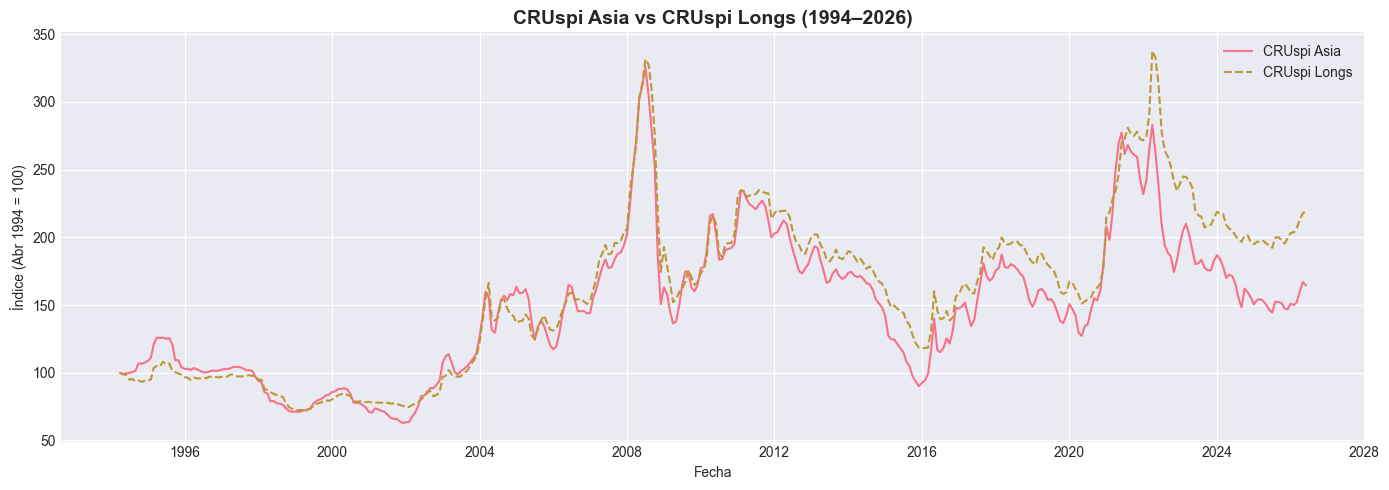

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df['date'], df['cruspi_asia'], label='CRUspi Asia', linewidth=1.5)
ax.plot(df['date'], df['cruspi_longs'], label='CRUspi Longs', linewidth=1.5, linestyle='--')

ax.set_title('CRUspi Asia vs CRUspi Longs (1994–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Índice (Abr 1994 = 100)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../outputs/01_serie_temporal.png', dpi=150)
plt.show()

Ya unificado los valores podemos sacar datos estadisticos de utilidad, asi como el coeficiente de Pearson para ver que tanto se relacionan historicamente

In [12]:
print("=== ESTADÍSTICAS DESCRIPTIVAS ===\n")
print(df[['cruspi_asia', 'cruspi_longs']].describe().round(2))

print("\n=== VARIACIÓN TOTAL ===")
for col in ['cruspi_asia', 'cruspi_longs']:
    inicio = df[col].iloc[0]
    maximo = df[col].max()
    fecha_max = df.loc[df[col].idxmax(), 'date'].strftime('%b %Y')
    minimo = df[col].min()
    fecha_min = df.loc[df[col].idxmin(), 'date'].strftime('%b %Y')
    print(f"\n{col}:")
    print(f"  Máximo: {maximo:.1f} ({fecha_max})")
    print(f"  Mínimo: {minimo:.1f} ({fecha_min})")
    print(f"  Variación desde origen: {((df[col].iloc[-1]/inicio)-1)*100:.1f}%")

=== ESTADÍSTICAS DESCRIPTIVAS ===

       cruspi_asia  cruspi_longs
count       387.00        387.00
mean        148.23        160.21
std          51.26         59.48
min          62.93         71.82
25%         103.77         98.51
50%         150.71        161.86
75%         177.41        197.24
max         325.97        337.63

=== VARIACIÓN TOTAL ===

cruspi_asia:
  Máximo: 326.0 (Jul 2008)
  Mínimo: 62.9 (Dec 2001)
  Variación desde origen: 64.5%

cruspi_longs:
  Máximo: 337.6 (Apr 2022)
  Mínimo: 71.8 (Jan 1999)
  Variación desde origen: 118.8%


Correlación de Pearson: 0.9572  (p-value: 2.26e-209)


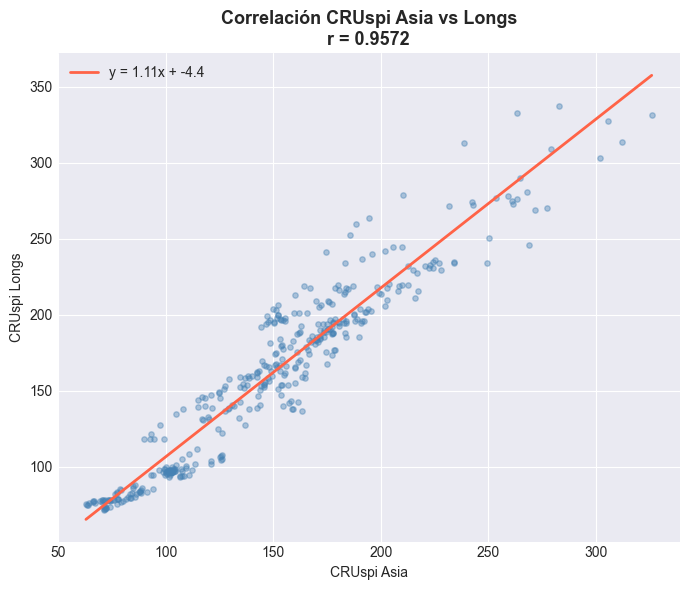

In [13]:
from scipy import stats

# Correlación de Pearson
r, p = stats.pearsonr(df['cruspi_asia'], df['cruspi_longs'])
print(f"Correlación de Pearson: {r:.4f}  (p-value: {p:.2e})")

# Scatter plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df['cruspi_asia'], df['cruspi_longs'], alpha=0.4, s=15, color='steelblue')

# Línea de regresión
m, b, _, _, _ = stats.linregress(df['cruspi_asia'], df['cruspi_longs'])
x_line = pd.Series([df['cruspi_asia'].min(), df['cruspi_asia'].max()])
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label=f'y = {m:.2f}x + {b:.1f}')

ax.set_title(f'Correlación CRUspi Asia vs Longs\nr = {r:.4f}', fontsize=13, fontweight='bold')
ax.set_xlabel('CRUspi Asia')
ax.set_ylabel('CRUspi Longs')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/02_correlacion.png', dpi=150)
plt.show()